# Customer Segmentation for a UK Online Retailer
## RFM-based clustering to replace generic marketing campaigns

**IIB415A · Business Intelligence · Universidad del Desarrollo**
Prof. Christopher Castro Araya, MSc. · Semester 2026

**Team 4**

| # | Member | Student ID |
|---|--------|-----------|
| 1 | Nicolas Bravo | 20431749-6 |
| 2 | Maria Jose Lopez | 21675751-3 |
| 3 | Matias Mouat | 21610229-0 |
| 4 | Martin Olivares | 21644638-0 |
| 5 | Santiago Page | 21612007-8 |

**Dataset:** Online Retail — UCI Machine Learning Repository
**Source:** https://archive.ics.uci.edu/dataset/352/online+retail

---

### How to read this notebook

The notebook follows the five stages of the BI pipeline required by the assignment:

| Stage | Content | Section |
|-------|---------|---------|
| 1 | Frame and KPIs | §1 |
| 2 | Prepare data | §2 |
| 3 | Model and evaluate | §3 |
| 4 | Communicate | §4 |
| 5 | Ethics and limitations | §5 |

Every result is produced by the cells below. A fresh **Restart & Run All** reproduces
every number and every figure with no manual steps. The random seed is fixed at the top.

---
# 1 · Frame and KPIs

## 1.1 The client and the problem

Our team acts as an external Business Intelligence unit hired by the **marketing department
of a UK-based online gift retailer**. The company sells mostly to small business customers
across Europe through its website.

Today the marketing team sends **the same campaign to the entire customer base**. Every
customer receives the same email, the same discount and the same reminder frequency.
This is expensive and inefficient: loyal high-spend customers receive discounts they did
not need, and customers who are about to churn receive nothing that would bring them back.

## 1.2 Business question

> **How can we group our customers by purchasing behaviour so that marketing budget is
> allocated to the customers where it actually changes behaviour, instead of being spread
> uniformly across everyone?**

## 1.3 Decision-maker and the decision

| | |
|---|---|
| **Decision-maker** | Head of CRM / Marketing Manager |
| **Decision to be taken** | How to allocate the quarterly retention budget across the customer base |
| **What changes because of our work** | The single generic campaign is replaced by a small number of differentiated treatments (retention offer, loyalty reward, reactivation, low-cost nurture), each assigned to a segment |
| **Unit of analysis** | One row = one customer (`CustomerID`) |

## 1.4 Why segmentation and not prediction

There is no labelled target in this dataset telling us which customer is "valuable" or
"about to churn". Any such label would have to be invented by us, and the model would then
simply be learning our own arbitrary rule. The honest technique for this question is
**unsupervised segmentation**: we let the purchasing behaviour itself define the groups.

## 1.5 KPIs and success metric

**Business KPIs** the segmentation is meant to move:

| KPI | Definition | Why it matters here |
|-----|-----------|---------------------|
| Revenue concentration | % of revenue coming from the top segment | Tells marketing where the money actually is |
| Customer retention rate | % of customers who purchase again in the next period | The main lever the campaign is trying to move |
| Marketing cost per customer | Campaign spend / customers contacted | Segmentation should let us spend less on low-potential customers |
| Average order value (AOV) | Revenue / number of invoices | Detects whether offers are cannibalising margin |

**Technical success metric (what we can measure inside this notebook):**

- **Silhouette score** on a **held-out set of customers** — measures whether the segments
  are internally coherent and well separated, on data the model never saw.
- **Business interpretability** — every cluster must be describable in one sentence that a
  marketing manager can act on. A statistically clean cluster that nobody can name is a
  failed cluster.

Every segment must also receive a **distinct marketing action** — a statistically clean
cluster that nobody can name is a failed cluster.

---
## 1.6 Environment and reproducibility

One seed is defined here and reused everywhere. No other cell defines a seed.

In [1]:
# --- Standard library
import warnings
import base64
import io
from datetime import timedelta

# --- Third party (course stack)
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

# --- Reproducibility: single seed for the whole notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Plot style (kept simple and readable on a projector)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = ["#0B6E6E", "#D98C1F", "#3E6B9B", "#A6484A", "#6B8E4E", "#7A5C99"]

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", matplotlib.__version__)
import sklearn
print("scikit-learn", sklearn.__version__)
print("RANDOM_STATE", RANDOM_STATE)

pandas       2.2.2
numpy        1.26.4
matplotlib   3.9.2
scikit-learn 1.5.1
RANDOM_STATE 42


---
# 2 · Prepare data

## 2.1 Loading the dataset

The file `Online Retail.xlsx` is included in the submission ZIP. It can also be downloaded
from the UCI Machine Learning Repository (link in the README).

`CustomerID` is read as a string on purpose: it is an **identifier**, not a quantity. Read
as a float it would print as `17850.0` and pandas would happily compute its mean, which is
meaningless.

In [2]:
# Path to the dataset. Change only this line if the file lives somewhere else.
DATA_PATH = "Online Retail.xlsx"

df_raw = pd.read_excel(DATA_PATH, dtype={"CustomerID": str})

print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 541,909   Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


### Data dictionary

| Column | Type | Meaning |
|--------|------|---------|
| `InvoiceNo` | categorical | Invoice number. A code starting with **C** marks a **cancellation** |
| `StockCode` | categorical | Product code |
| `Description` | text | Product name |
| `Quantity` | numeric | Units per line. Negative on cancellations/returns |
| `InvoiceDate` | datetime | Timestamp of the transaction |
| `UnitPrice` | numeric | Price per unit, in GBP |
| `CustomerID` | categorical | Customer identifier. **Missing for a large share of rows** |
| `Country` | categorical | Country of the customer |

The dataset mixes numeric (`Quantity`, `UnitPrice`) and categorical (`StockCode`,
`Country`, `InvoiceNo`) fields and covers roughly one year of real transactions, which
satisfies the dataset requirements of the assignment.

## 2.2 Exploratory data analysis — what is wrong with this data

Before cleaning anything we measure the problems. Every cleaning decision in §2.3 is
justified by a number produced here.

In [4]:
# --- Missing values
missing = pd.DataFrame({
    "n_missing": df_raw.isna().sum(),
    "pct_missing": (df_raw.isna().mean() * 100).round(2),
})
missing = missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)
print("MISSING VALUES")
print(missing.to_string() if len(missing) else "  none")

MISSING VALUES
             n_missing  pct_missing
CustomerID      135080        24.93
Description       1454         0.27


In [5]:
# --- Quality issues, quantified
n = len(df_raw)
cancelled   = df_raw["InvoiceNo"].astype(str).str.startswith("C")
neg_qty     = df_raw["Quantity"] <= 0
zero_price  = df_raw["UnitPrice"] <= 0
dupes       = df_raw.duplicated()
no_customer = df_raw["CustomerID"].isna()

issues = pd.DataFrame({
    "issue": [
        "Cancellation invoices (InvoiceNo starts with 'C')",
        "Quantity <= 0",
        "UnitPrice <= 0",
        "Exact duplicate rows",
        "Missing CustomerID",
    ],
    "rows": [cancelled.sum(), neg_qty.sum(), zero_price.sum(), dupes.sum(), no_customer.sum()],
})
issues["pct_of_total"] = (issues["rows"] / n * 100).round(2)
print(f"Total rows: {n:,}\n")
print(issues.to_string(index=False))

Total rows: 541,909

                                            issue   rows  pct_of_total
Cancellation invoices (InvoiceNo starts with 'C')   9288          1.71
                                    Quantity <= 0  10624          1.96
                                   UnitPrice <= 0   2517          0.46
                             Exact duplicate rows   5268          0.97
                               Missing CustomerID 135080         24.93


In [6]:
# --- Numeric distributions before cleaning: note the extreme range
print("QUANTITY")
print(df_raw["Quantity"].describe().round(2).to_string())
print("\nUNIT PRICE")
print(df_raw["UnitPrice"].describe().round(2).to_string())
print("\nDATE RANGE")
print(f"  from {df_raw['InvoiceDate'].min()}  to  {df_raw['InvoiceDate'].max()}")

QUANTITY
count    541909.00
mean          9.55
std         218.08
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00

UNIT PRICE
count    541909.00
mean          4.61
std          96.76
min      -11062.06
25%           1.25
50%           2.08
75%           4.13
max       38970.00

DATE RANGE
  from 2010-12-01 08:26:00  to  2011-12-09 12:50:00


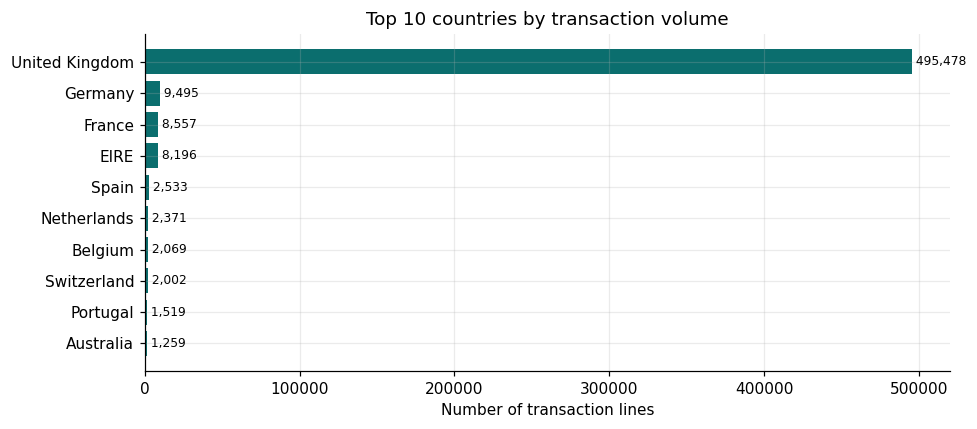

United Kingdom accounts for 91.4% of all transaction lines.
Distinct countries: 38


In [7]:
# --- Where do the customers come from?
country_counts = df_raw["Country"].value_counts()
top_countries = country_counts.head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE[0])
ax.set_xlabel("Number of transaction lines")
ax.set_title("Top 10 countries by transaction volume")
for i, v in enumerate(top_countries.values[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

uk_share = (df_raw["Country"] == "United Kingdom").mean() * 100
print(f"United Kingdom accounts for {uk_share:.1f}% of all transaction lines.")
print(f"Distinct countries: {df_raw['Country'].nunique()}")

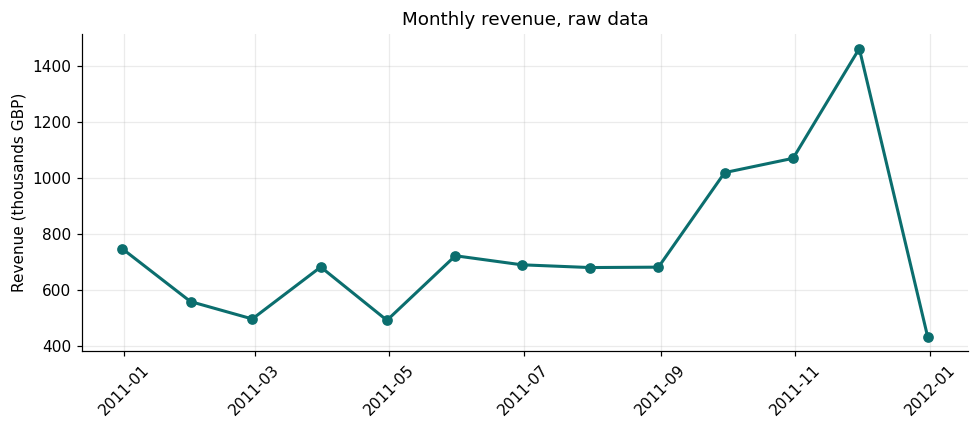

Note: the first and last months are partial, and there is a strong
pre-Christmas peak. This seasonality is discussed as a limitation in §5.


In [8]:
# --- Monthly revenue: is the year complete and stable?
tmp = df_raw.copy()
tmp["Revenue"] = tmp["Quantity"] * tmp["UnitPrice"]
monthly = tmp.set_index("InvoiceDate")["Revenue"].resample("ME").sum() / 1000

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, marker="o", color=PALETTE[0], linewidth=2)
ax.set_ylabel("Revenue (thousands GBP)")
ax.set_title("Monthly revenue, raw data")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Note: the first and last months are partial, and there is a strong")
print("pre-Christmas peak. This seasonality is discussed as a limitation in §5.")
del tmp

### What the EDA tells us

1. **`CustomerID` is missing on a large block of rows.** These are almost certainly
   over-the-counter or unregistered sales. They cannot be attributed to a customer, and our
   unit of analysis *is* the customer, so they are unusable for this project.
2. **Cancellations exist and carry negative quantities.** Left in, they would deflate a
   customer's monetary value and corrupt the invoice count.
3. **`UnitPrice` includes zeros and negatives.** These are administrative adjustments
   (bad debt, manual corrections), not sales.
4. **Exact duplicate rows exist**, probably from the extraction process.
5. **The data is dominated by the United Kingdom** and covers roughly one year.

Each of these becomes an explicit cleaning step below.

## 2.3 Cleaning

We apply the steps in a fixed order and **log how many rows each one removes**, so that the
grader (and we, in Q&A) can see exactly what was dropped and why. Nothing is dropped
silently.

| Step | Rule | Justification |
|------|------|---------------|
| 1 | Drop exact duplicate rows | Extraction artefacts; they would double-count spend |
| 2 | Drop rows with missing `CustomerID` | Cannot be attributed to a customer; the customer is our unit of analysis |
| 3 | Drop cancellation invoices (`InvoiceNo` starts with `C`) | Not purchases. Removing the whole invoice, not just the negative line |
| 4 | Drop `Quantity <= 0` | Returns and corrections, not purchase behaviour |
| 5 | Drop `UnitPrice <= 0` | Free items and administrative adjustments carry no monetary signal |

**Why we do not impute the missing `CustomerID`.** Imputation invents a customer who does
not exist. Any imputed ID would create a fake purchase history and fabricate a segment.
Deletion loses data but keeps the analysis honest; the consequence is stated in §5.

In [9]:
df = df_raw.copy()
log = []

def drop(mask, reason):
    global df
    before = len(df)
    df = df.loc[~mask].copy()
    removed = before - len(df)
    log.append({"step": reason, "rows_removed": removed, "rows_left": len(df)})

drop(df.duplicated(),                                    "1. Exact duplicate rows")
drop(df["CustomerID"].isna(),                            "2. Missing CustomerID")
drop(df["InvoiceNo"].astype(str).str.startswith("C"),    "3. Cancellation invoices")
drop(df["Quantity"] <= 0,                                "4. Quantity <= 0")
drop(df["UnitPrice"] <= 0,                               "5. UnitPrice <= 0")

cleaning_log = pd.DataFrame(log)
cleaning_log["pct_of_original"] = (cleaning_log["rows_removed"] / len(df_raw) * 100).round(2)
print("CLEANING LOG")
print(cleaning_log.to_string(index=False))
print(f"\nOriginal rows : {len(df_raw):,}")
print(f"Remaining rows: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% of original)")
print(f"Distinct customers: {df['CustomerID'].nunique():,}")

CLEANING LOG
                    step  rows_removed  rows_left  pct_of_original
 1. Exact duplicate rows          5268     536641             0.97
   2. Missing CustomerID        135037     401604            24.92
3. Cancellation invoices          8872     392732             1.64
        4. Quantity <= 0             0     392732             0.00
       5. UnitPrice <= 0            40     392692             0.01

Original rows : 541,909
Remaining rows: 392,692  (72.5% of original)
Distinct customers: 4,338


In [10]:
# --- Derived line-level value
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Revenue"]].describe().round(2).to_string())
print(f"\nTotal revenue in cleaned data: GBP {df['Revenue'].sum():,.0f}")

        Quantity  UnitPrice    Revenue
count  392692.00  392692.00  392692.00
mean       13.12       3.13      22.63
std       180.49      22.24     311.10
min         1.00       0.00       0.00
25%         2.00       1.25       4.95
50%         6.00       1.95      12.45
75%        12.00       3.75      19.80
max     80995.00    8142.75  168469.60

Total revenue in cleaned data: GBP 8,887,209


## 2.4 Feature engineering — building the RFM table

The raw data is one row per **invoice line**. Our unit of analysis is the **customer**, so
we aggregate up to one row per `CustomerID` and build the three classic RFM features.

| Feature | Definition | Business meaning | Direction |
|---------|-----------|------------------|-----------|
| **Recency** | Days between the customer's last purchase and the snapshot date | How likely they still are an active customer | **Lower is better** |
| **Frequency** | Number of distinct invoices | How habitual the relationship is | Higher is better |
| **Monetary** | Total revenue generated | How much the relationship is worth | Higher is better |

**The snapshot date.** Recency has to be measured against a fixed reference point. We use
**the day after the last transaction in the dataset**. Using "today" (`pd.Timestamp.now()`)
would be wrong: the data ends in 2011, so every customer would look inactive by thousands
of days and Recency would carry no information at all. Using a hard-coded date would break
reproducibility if the dataset were updated. Deriving it from the data keeps the notebook
correct and reproducible.

**Why Frequency counts invoices, not lines.** A customer who buys 40 different products in
one order made **one** purchase decision, not 40. Counting lines would confuse basket size
with loyalty.

In [11]:
# --- Snapshot date: one day after the last transaction observed
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)
print(f"Last transaction : {df['InvoiceDate'].max()}")
print(f"Snapshot date    : {snapshot_date}")

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
)

# Keep the customer's country for later profiling (their most frequent country)
customer_country = df.groupby("CustomerID")["Country"].agg(lambda s: s.mode().iat[0])
rfm["Country"] = customer_country

print(f"\nCustomers in RFM table: {len(rfm):,}")
rfm.head(10)

Last transaction : 2011-12-09 12:50:00
Snapshot date    : 2011-12-10 12:50:00

Customers in RFM table: 4,338


,Recency,Frequency,Monetary,Country
CustomerID,,,,
12346,326,1,77183.60,United Kingdom
12347,2,7,4310.00,Iceland
12348,75,4,1797.24,Finland
12349,19,1,1757.55,Italy
12350,310,1,334.40,Norway
12352,36,8,2506.04,Norway
12353,204,1,89.00,Bahrain
12354,232,1,1079.40,Spain
12355,214,1,459.40,Bahrain


In [12]:
print("RFM SUMMARY")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2).to_string())
print("\nSKEWNESS (0 = symmetric)")
print(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2).to_string())

RFM SUMMARY
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02

SKEWNESS (0 = symmetric)
Recency       1.25
Frequency    12.07
Monetary     19.34


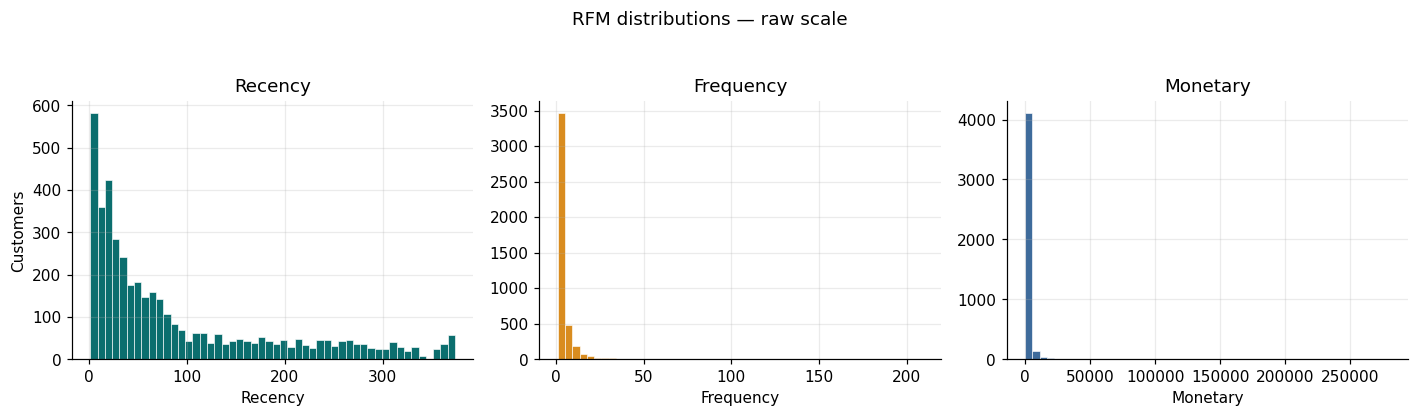

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], PALETTE):
    ax.hist(rfm[col], bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel(col)
axes[0].set_ylabel("Customers")
fig.suptitle("RFM distributions — raw scale", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

### The distributions are severely right-skewed

`Frequency` and `Monetary` have a very long right tail: most customers bought a handful of
times for a modest amount, and a small group bought constantly for very large amounts.

This matters because **K-means minimises squared Euclidean distance**. With a raw skewed
scale, a handful of extreme customers dominate the objective function, and the algorithm
spends its clusters isolating them instead of describing the bulk of the customer base.

## 2.5 Outliers — inspect first, then decide

We look at the extremes explicitly before deciding what to do with them.

In [15]:
print("TOP 10 CUSTOMERS BY MONETARY VALUE")
print(rfm.nlargest(10, "Monetary")[["Recency", "Frequency", "Monetary", "Country"]].round(0).to_string())

q99 = rfm["Monetary"].quantile(0.99)
top1 = rfm[rfm["Monetary"] >= q99]
print(f"\nThe top 1% of customers ({len(top1)} customers) generate "
      f"{top1['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}% of total revenue.")

TOP 10 CUSTOMERS BY MONETARY VALUE
            Recency  Frequency  Monetary         Country
CustomerID                                              
14646             2         73  280206.0     Netherlands
18102             1         60  259657.0  United Kingdom
17450             8         46  194391.0  United Kingdom
16446             1          2  168472.0  United Kingdom
14911             1        201  143711.0            EIRE
12415            24         21  124915.0       Australia
14156            10         55  117210.0            EIRE
17511             3         31   91062.0  United Kingdom
16029            39         63   80851.0  United Kingdom
12346           326          1   77184.0  United Kingdom

The top 1% of customers (44 customers) generate 32.1% of total revenue.


**Decision: we keep the outliers, and we transform the scale instead of deleting rows.**

These extreme customers are not data errors — they are wholesale buyers, and they are the
single most commercially important group in the file. Deleting them would remove exactly
the customers the marketing department most needs to identify.

Instead we apply a **`log1p` transformation** to the three features. `log1p(x) = log(1 + x)`
compresses the long tail while preserving the ordering, and is safe at zero (Recency can be
0 for a customer who bought on the last day). After the transform, distances between typical
customers and extreme customers become comparable, so K-means describes the whole base
rather than chasing a few whales.

We only remove records that are logically impossible, and we verify that there are none.

In [16]:
impossible = (rfm["Monetary"] <= 0) | (rfm["Frequency"] <= 0) | (rfm["Recency"] < 0)
print(f"Logically impossible RFM records: {impossible.sum()}")
rfm = rfm.loc[~impossible].copy()

FEATURES = ["Recency", "Frequency", "Monetary"]
rfm_log = np.log1p(rfm[FEATURES])

print("\nSKEWNESS BEFORE -> AFTER log1p")
comparison = pd.DataFrame({
    "before": rfm[FEATURES].skew().round(2),
    "after":  rfm_log.skew().round(2),
})
print(comparison.to_string())

Logically impossible RFM records: 0

SKEWNESS BEFORE -> AFTER log1p
           before  after
Recency      1.25  -0.38
Frequency   12.07   1.21
Monetary    19.34   0.40


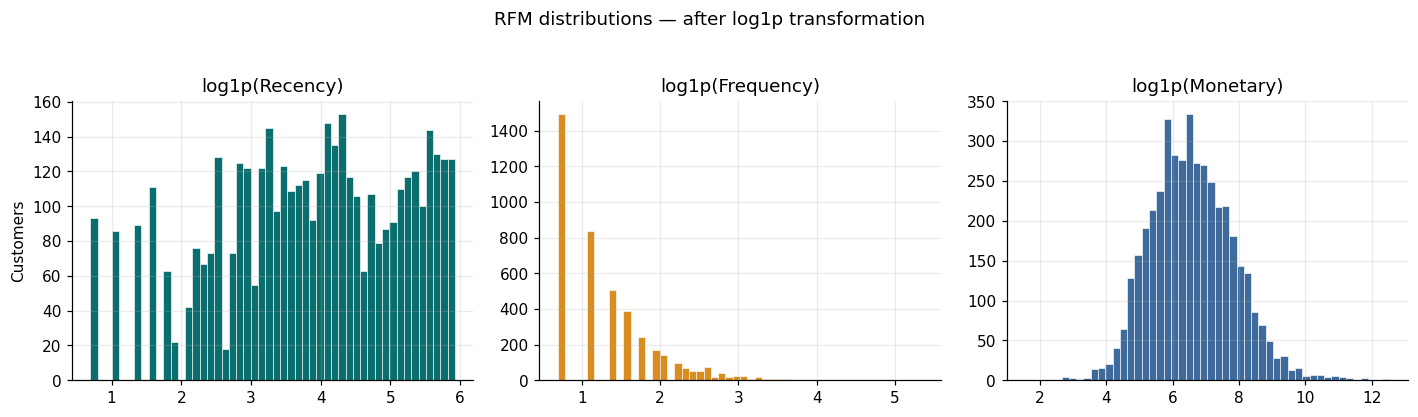

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, color in zip(axes, FEATURES, PALETTE):
    ax.hist(rfm_log[col], bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(f"log1p({col})")
axes[0].set_ylabel("Customers")
fig.suptitle("RFM distributions — after log1p transformation", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

## 2.6 Train / test split — and why we split at all

K-means is unsupervised, so there is no target to leak. But "no target" is not the same as
"no validation". A clustering solution can be **overfitted to the specific customers it was
fitted on**: the centroids land exactly where those points happen to be, and the structure
falls apart on customers the model never saw.

So we run the same discipline as in supervised learning:

**split → fit → predict → evaluate**

1. **Split** the customers into 80% train / 20% test.
2. **Fit** the `StandardScaler` and the `KMeans` model **on the training customers only**.
3. **Predict** cluster labels for the test customers using the already-fitted objects.
4. **Evaluate** the silhouette score on the test set — customers the model has never seen.

**This is where leakage would happen if we were careless.** If we called
`scaler.fit_transform()` on the *full* RFM table before splitting, the mean and standard
deviation used to scale the training data would already contain information from the test
customers. The test evaluation would then be optimistic and we would not know by how much.
We therefore call `fit_transform` on train and `transform` (never `fit`) on test.

Note also **why standardisation is required at all**: after `log1p`, Recency runs roughly
0–6, Frequency 0–5 and Monetary 3–13. Euclidean distance would let Monetary dominate purely
because its numbers are bigger. `StandardScaler` puts all three on mean 0 / standard
deviation 1 so that each dimension carries equal weight.

In [19]:
# --- 1. SPLIT (on customers, before any scaling)
X_train_raw, X_test_raw = train_test_split(
    rfm_log, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training customers: {len(X_train_raw):,}")
print(f"Test customers    : {len(X_test_raw):,}")

# --- 2. FIT the scaler on TRAIN ONLY  (no leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # transform ONLY on test

print("\nScaler parameters were learned from the training set only:")
print(pd.DataFrame({"mean": scaler.mean_, "std": scaler.scale_}, index=FEATURES).round(3).to_string())
print(f"\nTrain matrix shape: {X_train.shape}   Test matrix shape: {X_test.shape}")

Training customers: 3,470
Test customers    : 868

Scaler parameters were learned from the training set only:
            mean    std
Recency    3.826  1.333
Frequency  1.340  0.676
Monetary   6.579  1.256

Train matrix shape: (3470, 3)   Test matrix shape: (868, 3)


---
# 3 · Model and evaluate

## 3.1 Choosing the algorithm

**K-means** is the appropriate algorithm here:

- The three RFM features are continuous and, after `log1p`, roughly unimodal.
- We need **compact, describable groups** with a representative centre. A centroid is
  directly readable by a marketing manager: "this segment's average customer last bought
  30 days ago, has ordered 8 times and spent GBP 3,000."
- The customer base is a few thousand rows, so the algorithm is fast enough to re-run
  across many values of k.

**What we considered and rejected:**

| Alternative | Why not here |
|---|---|
| Hierarchical clustering | O(n^2) memory; no centroid to hand to marketing |
| DBSCAN | Designed to find arbitrary shapes and label noise. RFM space has no natural density gaps, and a large "noise" group is useless for a campaign |
| Manual RFM quintile scoring | We use it as the **baseline** in §3.5, not as the model |

K-means is run with `n_init=10`: the algorithm is restarted from 10 different random
initialisations and the best result is kept. This is what makes the solution stable rather
than dependent on one lucky starting point. `random_state=42` makes those 10
initialisations identical on every run, which is what gives us reproducibility.

## 3.2 Choosing k — elbow and silhouette

`k` is a decision we have to justify, not a number we guess. We use two criteria and cross
them with a third, business one.

- **Inertia (elbow method):** within-cluster sum of squares. It always decreases as k grows,
  so we look for the bend where extra clusters stop buying much improvement.
- **Silhouette score:** for each point, how much closer it is to its own cluster than to the
  nearest other cluster. Ranges from -1 to 1; higher is better.

Both are computed **on the training set only**. The test set is not touched until §3.4.

In [20]:
k_range = range(2, 11)
results = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_tr = km.fit_predict(X_train)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_train, labels_tr),
    })

k_search = pd.DataFrame(results).set_index("k")
print("MODEL SELECTION (training set)")
print("  inertia    : lower is better, but always falls as k grows")
print("  silhouette : higher is better\n")
print(k_search.round(3).to_string())

MODEL SELECTION (training set)
  inertia    : lower is better, but always falls as k grows
  silhouette : higher is better

     inertia  silhouette
k                       
2   5182.819       0.433
3   3903.764       0.334
4   3158.211       0.336
5   2659.719       0.314
6   2304.362       0.308
7   2056.979       0.306
8   1883.877       0.299
9   1744.671       0.279
10  1622.678       0.275


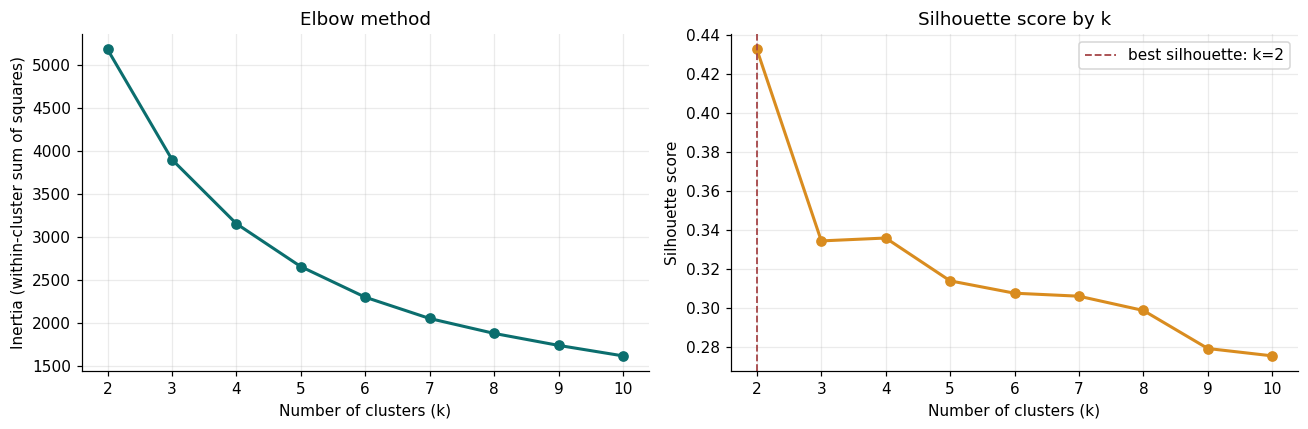

k with the highest silhouette on train: 2 (0.433)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_search.index, k_search["inertia"], marker="o", color=PALETTE[0], linewidth=2)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method")

axes[1].plot(k_search.index, k_search["silhouette"], marker="o", color=PALETTE[1], linewidth=2)
best_k_metric = int(k_search["silhouette"].idxmax())
axes[1].axvline(best_k_metric, color=PALETTE[3], linestyle="--", linewidth=1.2,
                label=f"best silhouette: k={best_k_metric}")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"k with the highest silhouette on train: {best_k_metric} "
      f"({k_search['silhouette'].max():.3f})")

### The decision on k

The metrics above give a purely statistical ranking. The business adds a second constraint:

> **Every segment must map to a marketing action the department can actually fund and
> execute.** With k = 2 the segmentation says nothing more than "good customers and bad
> customers", which marketing already knows. With k = 9 or 10 the team would have to design
> nine different campaigns, and several segments would be too small to justify one.

We therefore choose **k = 4**, provided its silhouette is close to the statistical optimum.
Four segments is the range the CRM team can operate: one retention treatment, one loyalty
treatment, one reactivation treatment and one low-cost nurture treatment.

The cell below states the chosen value, prints the cost of that choice in silhouette points
against the statistical best, and is the single place to change k if the grader wants to
explore another value.

In [22]:
K = 4   # <-- the chosen number of segments

cost = k_search.loc[best_k_metric, "silhouette"] - k_search.loc[K, "silhouette"]
print(f"Chosen k                       : {K}")
print(f"Silhouette at k={K} (train)      : {k_search.loc[K, 'silhouette']:.3f}")
print(f"Best statistical k             : {best_k_metric}")
print(f"Silhouette at best k (train)   : {k_search.loc[best_k_metric, 'silhouette']:.3f}")
print(f"Cost of the business choice    : {cost:.3f} silhouette points")

Chosen k                       : 4
Silhouette at k=4 (train)      : 0.336
Best statistical k             : 2
Silhouette at best k (train)   : 0.433
Cost of the business choice    : 0.097 silhouette points


## 3.3 Fit on train

The model is fitted **only on the training customers**.

In [23]:
# --- 3. FIT on train
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_train)

train_labels = kmeans.labels_
print(f"Model fitted on {len(X_train):,} training customers.")
print(f"Converged in {kmeans.n_iter_} iterations.")
print("\nCluster sizes in the training set:")
print(pd.Series(train_labels).value_counts().sort_index().to_string())

Model fitted on 3,470 training customers.
Converged in 19 iterations.

Cluster sizes in the training set:
0     667
1    1296
2     936
3     571


## 3.4 Predict on the held-out customers and evaluate honestly

The model now assigns clusters to customers it has never seen. If the segmentation is real
structure and not an artefact of the training sample, the test silhouette should be close to
the training silhouette. A large drop would mean the clusters were fitted to noise.

In [24]:
# --- 4. PREDICT on test
test_labels = kmeans.predict(X_test)

# --- 5. EVALUATE
sil_train = silhouette_score(X_train, train_labels)
sil_test  = silhouette_score(X_test,  test_labels)

evaluation = pd.DataFrame({
    "Silhouette score": [sil_train, sil_test],
}, index=["Train", "Test (held-out)"])

print("EVALUATION")
print(evaluation.round(3).to_string())
print(f"\nSilhouette drop train -> test: {sil_train - sil_test:+.4f}")
print("A small drop means the segment structure generalises to unseen customers.")

EVALUATION
                 Silhouette score
Train                       0.336
Test (held-out)             0.337

Silhouette drop train -> test: -0.0008
A small drop means the segment structure generalises to unseen customers.


In [25]:
# --- Are the cluster proportions stable between train and test?
prop = pd.DataFrame({
    "train_%": pd.Series(train_labels).value_counts(normalize=True).sort_index() * 100,
    "test_%":  pd.Series(test_labels).value_counts(normalize=True).sort_index() * 100,
})
prop["difference"] = (prop["test_%"] - prop["train_%"]).round(2)
print("CLUSTER PROPORTIONS: TRAIN vs TEST")
print(prop.round(2).to_string())

CLUSTER PROPORTIONS: TRAIN vs TEST
   train_%  test_%  difference
0    19.22   19.24        0.02
1    37.35   36.98       -0.37
2    26.97   26.61       -0.36
3    16.46   17.17        0.71


## 3.5 Baselines — is K-means actually adding anything?

A metric without a reference point means nothing. We compare our model against the method
the client would realistically use instead.

**The baseline: traditional RFM quintile scoring.** This is what a marketing department does
today without a data science team: rank customers into quintiles on each of R, F and M, and
combine the scores into groups. It is a legitimate method, and it is the real alternative to
our proposal. If K-means cannot beat it, the honest recommendation is to use the simpler
method.

In [26]:
# --- Baseline: traditional RFM quintile scoring
def rfm_quintile_segments(frame, n_groups=K):
    scored = pd.DataFrame(index=frame.index)
    # Recency: LOW is good, so the ranking is reversed
    scored["R"] = pd.qcut(frame["Recency"].rank(method="first", ascending=False), 5, labels=[1,2,3,4,5]).astype(int)
    scored["F"] = pd.qcut(frame["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
    scored["M"] = pd.qcut(frame["Monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
    total = scored[["R", "F", "M"]].sum(axis=1)
    return pd.qcut(total.rank(method="first"), n_groups, labels=range(n_groups)).astype(int).values

baseline_labels = rfm_quintile_segments(rfm.loc[X_test_raw.index, FEATURES])
sil_baseline = silhouette_score(X_test, baseline_labels)

comparison = pd.DataFrame({
    "Method": ["Traditional RFM quintile scoring", f"K-means (k={K})"],
    "Silhouette on held-out test": [sil_baseline, sil_test],
})
print("BASELINE COMPARISON — all evaluated on the same held-out customers")
print(comparison.round(3).to_string(index=False))
print(f"\nImprovement of K-means over the quintile baseline: "
      f"{(sil_test - sil_baseline):+.3f} silhouette points")

BASELINE COMPARISON — all evaluated on the same held-out customers
                          Method  Silhouette on held-out test
Traditional RFM quintile scoring                        0.170
                   K-means (k=4)                        0.337

Improvement of K-means over the quintile baseline: +0.167 silhouette points


## 3.6 Assigning a segment to every customer

The evaluation above is complete. To produce the deliverable itself we now apply the
**already-fitted** pipeline to the whole customer base, so that every customer — not only
the 80% used for training — carries a segment.

Nothing is re-fitted here: we only call `transform` and `predict` with the scaler and the
model that were learned from the training set.

In [27]:
X_all = scaler.transform(rfm_log)
rfm["Cluster"] = kmeans.predict(X_all)

print(f"Segments assigned to all {len(rfm):,} customers.")
print("\nCluster sizes:")
print(rfm["Cluster"].value_counts().sort_index().to_string())

Segments assigned to all 4,338 customers.

Cluster sizes:
Cluster
0     834
1    1617
2    1167
3     720


---
# 4 · Communicate

## 4.1 Segment profiles

A cluster number is not a business object. We describe each cluster in the **original,
untransformed units** (days, orders, GBP), because that is the only version a marketing
manager can act on.

In [28]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency_days=("Recency", "mean"),
    Avg_Frequency_orders=("Frequency", "mean"),
    Avg_Monetary_GBP=("Monetary", "mean"),
    Median_Monetary_GBP=("Monetary", "median"),
    Total_Revenue_GBP=("Monetary", "sum"),
).round(1)

profile["Pct_of_Customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["Pct_of_Revenue"]   = (profile["Total_Revenue_GBP"] / profile["Total_Revenue_GBP"].sum() * 100).round(1)

print("SEGMENT PROFILES (original units)")
print(profile.to_string())

SEGMENT PROFILES (original units)
         Customers  Avg_Recency_days  Avg_Frequency_orders  Avg_Monetary_GBP  Median_Monetary_GBP  Total_Revenue_GBP  Pct_of_Customers  Pct_of_Revenue
Cluster                                                                                                                                               
0              834              18.7                   2.1             539.5                465.2           449953.6              19.2             5.1
1             1617             182.9                   1.3             348.4                298.2           563351.5              37.3             6.3
2             1167              69.7                   4.1            1801.0               1340.9          2101790.0              26.9            23.6
3              720              12.0                  13.7            8016.8               3710.7          5772113.8              16.6            64.9


## 4.2 Naming the segments

K-means returns clusters numbered 0, 1, 2, 3. Those numbers are arbitrary — they can
change if the seed changes — and they mean nothing to a marketing manager. So we derive the
names **from the profile table itself**, using a rule stated in advance:

1. **Champions** — the best composite of high Frequency, high Monetary and low Recency.
2. **Loyal Customers** — of the remaining segments, the one that is still buying (lowest
   average Recency).
3. **At Risk** — of the two inactive segments, the one that used to spend **more**.
4. **Low Engagement** — the remaining inactive, low-value segment.

Steps 3 and 4 are the important ones. A single composite ranking cannot separate "used to
be valuable and stopped" from "never really bought", because both can score the same overall
for completely different business reasons — and they need opposite marketing treatments.

In [29]:
# The naming rule is explicit and derived from the profile table, so it does not
# depend on the arbitrary cluster numbers that K-means happens to output.
#
#   1. Champions       = best composite of high Frequency, high Monetary, low Recency
#   2. Loyal Customers = of the rest, the segment that is still buying (lowest Recency)
#   3. At Risk         = of the two inactive segments, the one that used to spend MORE
#   4. Low Engagement  = the remaining inactive, low-value segment
#
# Steps 2-4 are what separate "stopped buying but was valuable" from "never really
# bought". A single composite ranking cannot tell those two apart, because they can
# score the same overall for completely different business reasons.

score = (
    profile["Avg_Frequency_orders"].rank(ascending=True)
    + profile["Avg_Monetary_GBP"].rank(ascending=True)
    + profile["Avg_Recency_days"].rank(ascending=False)   # low recency ranks high
)

if K == 4:
    champion = score.idxmax()
    rest     = [c for c in profile.index if c != champion]

    loyal    = profile.loc[rest, "Avg_Recency_days"].idxmin()      # still active
    inactive = [c for c in rest if c != loyal]

    at_risk  = profile.loc[inactive, "Avg_Monetary_GBP"].idxmax()  # was worth more
    low_eng  = [c for c in inactive if c != at_risk][0]

    segment_name = {
        champion: "Champions",
        loyal:    "Loyal Customers",
        at_risk:  "At Risk",
        low_eng:  "Low Engagement",
    }
    segment_desc = {
        champion: "Recent, frequent and high-spending. The core of the business.",
        loyal:    "Still buying regularly, with solid but smaller baskets.",
        at_risk:  "Used to spend meaningfully but have not returned in a long time.",
        low_eng:  "Few orders, low spend, long inactive. Mostly one-time buyers.",
    }
    order = ["Champions", "Loyal Customers", "At Risk", "Low Engagement"]
else:
    # Fallback so the notebook still runs if the grader changes K
    ranked = score.sort_values(ascending=False).index.tolist()
    segment_name = {c: f"Segment {i+1}" for i, c in enumerate(ranked)}
    segment_desc = {c: "Ranked by overall value and activity." for c in ranked}
    order = [f"Segment {i+1}" for i in range(K)]

rfm["Segment"] = rfm["Cluster"].map(segment_name)
profile["Segment"] = profile.index.map(segment_name)
profile["Description"] = profile.index.map(segment_desc)

summary = profile.set_index("Segment").loc[order][[
    "Customers", "Pct_of_Customers", "Avg_Recency_days",
    "Avg_Frequency_orders", "Avg_Monetary_GBP", "Pct_of_Revenue",
]]

print("SEGMENT SUMMARY")
print(summary.to_string())
print("\nCluster number -> business name")
for c in sorted(segment_name):
    print(f"  Cluster {c} -> {segment_name[c]}")

SEGMENT SUMMARY
                 Customers  Pct_of_Customers  Avg_Recency_days  Avg_Frequency_orders  Avg_Monetary_GBP  Pct_of_Revenue
Segment                                                                                                               
Champions              720              16.6              12.0                  13.7            8016.8            64.9
Loyal Customers        834              19.2              18.7                   2.1             539.5             5.1
At Risk               1167              26.9              69.7                   4.1            1801.0            23.6
Low Engagement        1617              37.3             182.9                   1.3             348.4             6.3

Cluster number -> business name
  Cluster 0 -> Loyal Customers
  Cluster 1 -> Low Engagement
  Cluster 2 -> At Risk
  Cluster 3 -> Champions


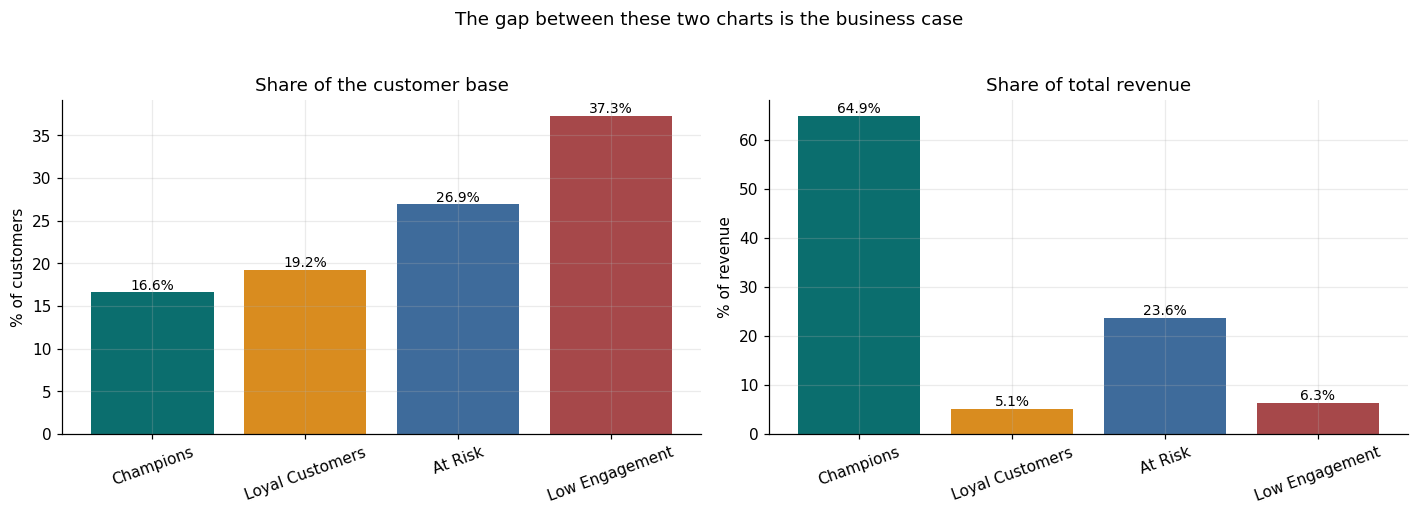

In [30]:
plot_df = profile.set_index("Segment").loc[order]
colors = PALETTE[:K]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(plot_df.index, plot_df["Pct_of_Customers"], color=colors)
axes[0].set_ylabel("% of customers")
axes[0].set_title("Share of the customer base")
for i, v in enumerate(plot_df["Pct_of_Customers"]):
    axes[0].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

axes[1].bar(plot_df.index, plot_df["Pct_of_Revenue"], color=colors)
axes[1].set_ylabel("% of revenue")
axes[1].set_title("Share of total revenue")
for i, v in enumerate(plot_df["Pct_of_Revenue"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("The gap between these two charts is the business case", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

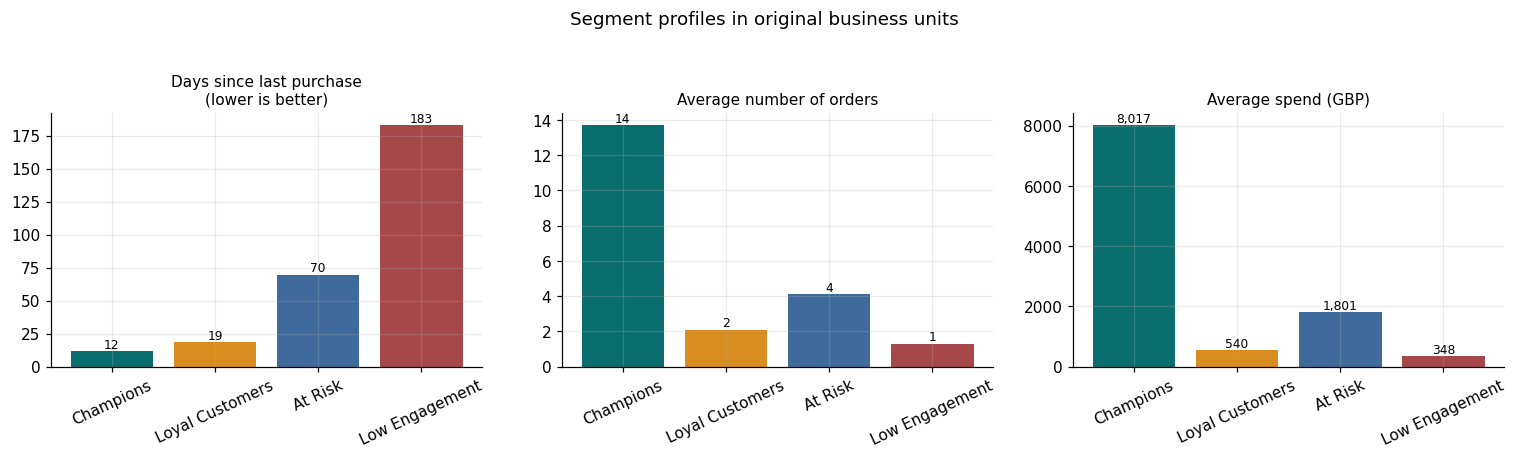

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("Avg_Recency_days", "Days since last purchase\n(lower is better)"),
           ("Avg_Frequency_orders", "Average number of orders"),
           ("Avg_Monetary_GBP", "Average spend (GBP)")]

for ax, (col, title) in zip(axes, metrics):
    ax.bar(plot_df.index, plot_df[col], color=colors)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=25)
    for i, v in enumerate(plot_df[col]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Segment profiles in original business units", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

## 4.3 From segments to actions

Each segment now receives one differentiated treatment. This table is the actual deliverable
to the client: it is the thing the Head of CRM will sign off and execute.

In [32]:
ACTIONS = {
    "Champions": {
        "Action": "Loyalty rewards, early access, no discount",
        "Reason": "They already buy at full price. Discounting them destroys margin we would have earned anyway",
        "Budget": "Medium spend, high return",
    },
    "Loyal Customers": {
        "Action": "Cross-sell and volume incentives to move them up",
        "Reason": "Consistent buyers with room to grow; the cheapest route to more Champions",
        "Budget": "Medium spend",
    },
    "At Risk": {
        "Action": "Win-back campaign: personal contact plus a time-limited offer",
        "Reason": "They spent real money before. Recovering one of them is far cheaper than acquiring a new customer",
        "Budget": "Highest priority for the retention budget",
    },
    "Low Engagement": {
        "Action": "Low-cost automated newsletter only; stop paid contact",
        "Reason": "Contribution does not justify per-contact cost; this is where the savings come from",
        "Budget": "Minimal spend",
    },
}

ACTIONS = {k: v for k, v in ACTIONS.items() if k in order}
action_table = pd.DataFrame(ACTIONS).T
action_table.index.name = "Segment"
action_table = action_table.join(summary[["Customers", "Pct_of_Revenue"]])
action_table = action_table.loc[order]

pd.set_option("display.max_colwidth", 90)
print("RECOMMENDED TREATMENT BY SEGMENT")
print(action_table.to_string())
pd.reset_option("display.max_colwidth")

RECOMMENDED TREATMENT BY SEGMENT
                                                                        Action                                                                                             Reason                                     Budget  Customers  Pct_of_Revenue
Segment                                                                                                                                                                                                                                                
Champions                           Loyalty rewards, early access, no discount       They already buy at full price. Discounting them destroys margin we would have earned anyway                  Medium spend, high return        720            64.9
Loyal Customers               Cross-sell and volume incentives to move them up                          Consistent buyers with room to grow; the cheapest route to more Champions                               Medium spend   

## 4.4 The recommendation

One recommendation, stated plainly for the Head of CRM.

In [33]:
champ  = summary.loc["Champions"]
risk   = summary.loc["At Risk"]
low    = summary.loc["Low Engagement"]

print("=" * 78)
print("RECOMMENDATION TO THE HEAD OF CRM".center(78))
print("=" * 78)
print()
print("Stop sending one campaign to everyone. Split the customer base into the four")
print("segments below and give each one a different treatment.")
print()
print(f"  1. CHAMPIONS are {champ['Pct_of_Customers']:.0f}% of customers but generate "
      f"{champ['Pct_of_Revenue']:.0f}% of revenue.")
print( "     Protect them with recognition and service, NOT with discounts. They already")
print( "     buy at full price; a discount here is margin given away for nothing.")
print()
print(f"  2. AT RISK is where the retention budget should go: {risk['Customers']:.0f} customers")
print(f"     who averaged GBP {risk['Avg_Monetary_GBP']:,.0f} and have not bought in "
      f"{risk['Avg_Recency_days']:.0f} days.")
print( "     They have already proved they will pay. Winning one back costs a fraction")
print( "     of acquiring a new customer.")
print()
print(f"  3. LOW ENGAGEMENT is {low['Pct_of_Customers']:.0f}% of the customer base but only "
      f"{low['Pct_of_Revenue']:.1f}% of revenue.")
print( "     Move them to a low-cost automated channel. This is the line item that")
print( "     funds the win-back campaign above.")
print()
print("HOW WE WILL KNOW IT WORKED (next quarter):")
print("  - Repeat-purchase rate in At Risk vs a held-out control group of At Risk customers")
print("  - Revenue per contacted customer, by segment")
print("  - Total marketing cost per customer (expected to fall)")
print("  - Retention rate among Champions (expected to hold, not fall)")
print("=" * 78)

                      RECOMMENDATION TO THE HEAD OF CRM                       

Stop sending one campaign to everyone. Split the customer base into the four
segments below and give each one a different treatment.

  1. CHAMPIONS are 17% of customers but generate 65% of revenue.
     Protect them with recognition and service, NOT with discounts. They already
     buy at full price; a discount here is margin given away for nothing.

  2. AT RISK is where the retention budget should go: 1167 customers
     who averaged GBP 1,801 and have not bought in 70 days.
     They have already proved they will pay. Winning one back costs a fraction
     of acquiring a new customer.

  3. LOW ENGAGEMENT is 37% of the customer base but only 6.3% of revenue.
     Move them to a low-cost automated channel. This is the line item that
     funds the win-back campaign above.

HOW WE WILL KNOW IT WORKED (next quarter):
  - Repeat-purchase rate in At Risk vs a held-out control group of At Risk customers
  - 

## 4.5 Dashboard

The cell below builds a **self-contained HTML dashboard** (`dashboard.html`) with the charts
embedded directly in the file, so it opens in any browser with no server, no data connection
and no external dependency. It is regenerated from the notebook on every run, so it can
never drift out of sync with the analysis.

In [35]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

# --- Chart A: customers vs revenue
figA, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(order)); w = 0.38
ax.bar(x - w/2, plot_df["Pct_of_Customers"], w, label="% of customers", color=PALETTE[2])
ax.bar(x + w/2, plot_df["Pct_of_Revenue"],   w, label="% of revenue",   color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15)
ax.set_ylabel("%"); ax.legend(frameon=False)
ax.set_title("Customer share vs revenue share")
chartA = fig_to_base64(figA)

# --- Chart C: average spend
figC, ax = plt.subplots(figsize=(8, 4))
ax.bar(order, plot_df["Avg_Monetary_GBP"], color=PALETTE[:K])
ax.set_ylabel("GBP"); ax.set_title("Average spend per customer")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(plot_df["Avg_Monetary_GBP"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
chartC = fig_to_base64(figC)

print("Charts encoded for the dashboard.")

Charts encoded for the dashboard.


In [36]:
kpi_total_customers = len(rfm)
kpi_total_revenue   = rfm["Monetary"].sum()
kpi_champ_rev       = summary.loc["Champions", "Pct_of_Revenue"]
kpi_atrisk_value    = rfm.loc[rfm["Segment"] == "At Risk", "Monetary"].sum()

# --- Build the segment table rows
rows_html = ""
for seg in order:
    r = summary.loc[seg]
    a = ACTIONS[seg]
    rows_html += (
        "<tr>"
        f"<td class='seg'>{seg}</td>"
        f"<td>{r['Customers']:,.0f}</td>"
        f"<td>{r['Pct_of_Customers']:.1f}%</td>"
        f"<td>{r['Avg_Recency_days']:.0f}</td>"
        f"<td>{r['Avg_Frequency_orders']:.1f}</td>"
        f"<td>&pound;{r['Avg_Monetary_GBP']:,.0f}</td>"
        f"<td>{r['Pct_of_Revenue']:.1f}%</td>"
        f"<td class='act'>{a['Action']}</td>"
        "</tr>"
    )

# --- CSS (kept as a plain string so no braces need escaping)
CSS = (
    "body{font-family:-apple-system,Segoe UI,Roboto,sans-serif;margin:0;"
    "background:#f4f6f7;color:#1b2b2b;}"
    "header{background:#0B6E6E;color:#fff;padding:26px 34px;}"
    "header h1{margin:0 0 4px;font-size:24px;font-weight:600;}"
    "header p{margin:0;opacity:.85;font-size:13px;}"
    ".wrap{max-width:1120px;margin:0 auto;padding:26px 20px 50px;}"
    ".kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(190px,1fr));"
    "gap:14px;margin-bottom:26px;}"
    ".kpi{background:#fff;border-radius:8px;padding:18px 20px;"
    "border-left:4px solid #D98C1F;box-shadow:0 1px 3px rgba(0,0,0,.07);}"
    ".kpi .v{font-size:27px;font-weight:700;color:#0B6E6E;}"
    ".kpi .l{font-size:11px;text-transform:uppercase;letter-spacing:.7px;"
    "color:#67787a;margin-top:5px;}"
    ".card{background:#fff;border-radius:8px;padding:20px 24px;margin-bottom:20px;"
    "box-shadow:0 1px 3px rgba(0,0,0,.07);}"
    ".card h2{margin:0 0 14px;font-size:16px;color:#0B6E6E;"
    "border-bottom:2px solid #eef1f1;padding-bottom:8px;}"
    ".grid2{display:grid;grid-template-columns:1fr 1fr;gap:20px;}"
    "img{max-width:100%;height:auto;display:block;}"
    "table{width:100%;border-collapse:collapse;font-size:13px;}"
    "th{background:#0B6E6E;color:#fff;padding:9px 10px;text-align:left;font-weight:600;}"
    "td{padding:9px 10px;border-bottom:1px solid #eef1f1;}"
    "tr:nth-child(even) td{background:#fafbfb;}"
    "td.seg{font-weight:700;color:#0B6E6E;}"
    "td.act{font-size:12px;color:#40585a;}"
    "footer{text-align:center;font-size:11px;color:#8a9a9c;padding:16px;}"
    "@media(max-width:820px){.grid2{grid-template-columns:1fr;}}"
)

# --- Assemble the page
html = (
    "<!DOCTYPE html><html lang='en'><head><meta charset='utf-8'>"
    "<title>Customer Segmentation Dashboard | Team 4</title>"
    f"<style>{CSS}</style></head><body>"
    "<header><h1>Customer Segmentation Dashboard</h1>"
    "<p>Online Retail &middot; RFM K-means segmentation &middot; Team 4 "
    "&middot; IIB415A Business Intelligence</p></header>"
    "<div class='wrap'>"

    "<div class='kpis'>"
    f"<div class='kpi'><div class='v'>{kpi_total_customers:,}</div>"
    "<div class='l'>Customers segmented</div></div>"
    f"<div class='kpi'><div class='v'>&pound;{kpi_total_revenue/1e6:.2f}M</div>"
    "<div class='l'>Total revenue analysed</div></div>"
    f"<div class='kpi'><div class='v'>{kpi_champ_rev:.0f}%</div>"
    "<div class='l'>Revenue from Champions</div></div>"
    f"<div class='kpi'><div class='v'>&pound;{kpi_atrisk_value/1000:,.0f}K</div>"
    "<div class='l'>Revenue at risk</div></div>"
    f"<div class='kpi'><div class='v'>{sil_test:.2f}</div>"
    "<div class='l'>Silhouette (held-out)</div></div>"
    "</div>"

    "<div class='card'><h2>Segments, profiles and recommended action</h2><table>"
    "<tr><th>Segment</th><th>Customers</th><th>% base</th><th>Recency (days)</th>"
    "<th>Orders</th><th>Avg spend</th><th>% revenue</th><th>Recommended action</th></tr>"
    f"{rows_html}</table></div>"

    "<div class='card'><h2>Customer share vs revenue share</h2>"
    f"<img src='data:image/png;base64,{chartA}' alt='Customer share versus revenue share'></div>"

    "<div class='card'><h2>Average spend per customer</h2>"
    f"<img src='data:image/png;base64,{chartC}' alt='Average spend per customer'></div>"

    "</div>"
    "<footer>Generated automatically from the project notebook &middot; "
    "Universidad del Desarrollo &middot; 2026</footer>"
    "</body></html>"
)

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("dashboard.html written successfully.")
print("Open it in any browser. It is fully self-contained (images embedded as base64).")

dashboard.html written successfully.
Open it in any browser. It is fully self-contained (images embedded as base64).


---
# 5 · Ethics, bias and limitations

## 5.1 Privacy

The dataset contains **no personal identifying information**: no names, no addresses, no
emails, no payment details. Customers appear only as a pseudonymous numeric ID. This is the
correct design for this analysis — we do not need to know *who* a customer is in order to
know *how* they buy.

Two things follow, and they matter in a real deployment:

- **Pseudonymous is not anonymous.** The retailer holds the mapping from `CustomerID` to a
  real business. Combined with our output, a segment label becomes personal data about an
  identifiable customer under the UK GDPR. The segment table must therefore be handled under
  the same access controls as the CRM itself.
- **Purpose limitation.** This data was collected to process orders. Using it to decide who
  receives marketing is a compatible secondary purpose, but reusing it for credit scoring or
  selling it on would not be, and we would not support it.

## 5.2 Bias in the data and in our own decisions

**Geographic bias.** The overwhelming majority of transactions are from the United Kingdom.
The segments are, in practice, a description of UK purchasing behaviour. Applying them to
customers in other markets — where delivery times, seasonality and typical order sizes
differ — would systematically misclassify them.

**Survivorship bias from dropping missing `CustomerID`.** We removed a large block of rows
with no customer ID. If unregistered purchases are more common among a particular type of
buyer, those buyers are simply absent from our segmentation and will never receive a
targeted treatment. We made the deletion for a good reason, but the cost is real and it is
not evenly distributed.

**Recency bias against seasonal customers.** A business that legitimately orders once a year,
in November, will show high Recency in a January snapshot and land in "At Risk" or "Low
Engagement". Our model cannot distinguish a lost customer from a seasonal one, because we
only have twelve months of data.

**Our own modelling choices are value judgements, not facts.** We chose `log1p`, we chose to
weight R, F and M equally through standardisation, and we chose k = 4. Each of these changes
who ends up in which segment. Equal weighting in particular is an assumption: the business
may well consider Monetary more important than Frequency, and if so the segments should be
rebuilt with that weighting made explicit.

## 5.3 The self-fulfilling prophecy risk

This is the most serious ethical issue in the project, and it is easy to miss.

If we tell the client to stop contacting "Low Engagement" customers, those customers receive
fewer offers, therefore buy less, therefore look even less engaged at the next refresh, and
are cut further. The model would then appear to be correct — but only because acting on it
made it correct.

**Mitigations we recommend to the client:**

- Keep a **control group** inside Low Engagement that continues to receive normal contact, so
  the effect of the policy can be measured rather than assumed.
- Never make the segment permanent. Recompute it every quarter so customers can move.
- Keep a **minimum baseline of contact** for every segment. Segmentation should reallocate
  attention, not delete customers from the business.

## 5.4 Honest limitations

| # | Limitation | Effect on the decision |
|---|---|---|
| 1 | Only ~12 months of data, with one Christmas peak | Cannot separate seasonal customers from churning ones |
| 2 | Data is from 2010–2011 | Behaviour patterns are dated; the method transfers, the specific thresholds do not |
| 3 | Rows without `CustomerID` were dropped | Part of the real customer base is invisible to the segmentation |
| 4 | The segmentation is descriptive, not causal | It says who is at risk, not why, and does not prove an intervention will work |

## 5.5 What we would do next

1. Run the win-back campaign on At Risk **as an A/B test against a holdout control**, and
   measure the actual lift instead of assuming it.
2. Add product-category and margin features, so that "high spend" can be separated from
   "high profit".
3. Refresh the segmentation quarterly and track how customers migrate between segments —
   the migration itself is a stronger KPI than the static snapshot.

---
# 6 · Exported artefacts

The cell below writes the files referenced by the README and the presentation.

In [ ]:
# --- Customer-level segmentation output (the deliverable to the client)
export = rfm.reset_index()[["CustomerID", "Recency", "Frequency", "Monetary",
                            "Country", "Cluster", "Segment"]]
export.to_csv("customer_segments.csv", index=False)

# --- Cleaned transaction data, compact format for the ZIP
try:
    df.to_parquet("online_retail_clean.parquet", index=False)
    data_file = "online_retail_clean.parquet"
except Exception as e:
    df.to_csv("online_retail_clean.csv", index=False)
    data_file = "online_retail_clean.csv"
    print(f"(parquet unavailable: {e} — wrote CSV instead)")

print("FILES WRITTEN")
for f in ["customer_segments.csv", data_file, "dashboard.html"]:
    print(f"  - {f}")

print("\nFINAL HEADLINE NUMBERS FOR THE SLIDES")
print(f"  Customers segmented        : {len(rfm):,}")
print(f"  Segments                   : {K}")
print(f"  Silhouette (held-out test) : {sil_test:.3f}")
print(f"  Silhouette (quintile base) : {sil_baseline:.3f}")
print(f"  Champions share of revenue : {summary.loc['Champions','Pct_of_Revenue']:.1f}%")
print(f"  Revenue sitting in At Risk : GBP {rfm.loc[rfm['Segment']=='At Risk','Monetary'].sum():,.0f}")

---
# 7 · AI use disclosure

In line with §7 of the assignment brief, Team 4 discloses the following.

**Tool used:** Claude (Anthropic), accessed through the web interface.

**What it was used for:**
- Discussing how to structure the notebook across the five required BI stages.
- Reviewing the wording of the English markdown narrative, since the team's working
  language is Spanish.
- Discussing the justification for specific technical choices (the `log1p` transformation,
  the train/test discipline for an unsupervised model, the choice of baselines).

**What it was NOT used for:**
- The business framing, the choice of dataset, the choice of k and the marketing
  recommendations are the team's own decisions.

**Verification.** Every cell in this notebook was executed and checked by the team. Every
number reported in the markdown comes from the output of the cell above it. Each member is
able to explain and defend the code in the sections listed in the contribution table of the
`README.md`.

---

*IIB415A · Business Intelligence · Universidad del Desarrollo · Team 4 · 2026*